# Medical Sound Classification

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision
import torchaudio
import librosa
import librosa.display
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# 1. Exploratory Analysis

## 1.1 Laad dataset

In [2]:
df_train = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

## 1.2 Bekijk class balance

In [3]:
df_train.head()

,candidateID,age,gender,tbContactHistory,wheezingHistory,phlegmCough,familyAsthmaHistory,feverHistory,coldPresent,packYears,disease
0,b87ea0dd760fa,43,1,0.0,1.0,0.0,0.0,0,NaN,0,1
1,b734834dec6d1,24,0,0.0,1.0,0.0,0.0,0,NaN,0,1
2,e000a41725f53,52,1,0.0,1.0,0.0,0.0,0,NaN,0,2
3,253ba780a0398,28,0,0.0,0.0,0.0,0.0,0,NaN,0,0
4,6663cd023ff3d,27,1,0.0,1.0,0.0,1.0,0,NaN,0,1


In [4]:
print(df_train['disease'].value_counts())


disease
1    238
2    168
0    140
Name: count, dtype: int64


Redelijk wat imbalance.

* 0 : 140
* 1 : 238
* 2 : 168

### 1.2.1 We plotten

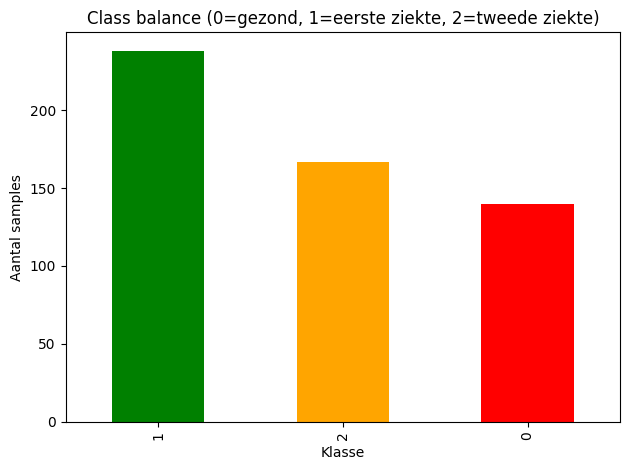

In [31]:
import matplotlib.pyplot as plt
df_train['disease'].value_counts().plot(kind='bar', color=['green', 'orange', 'red'])
plt.title('Class balance (0=gezond, 1=eerste ziekte, 2=tweede ziekte)')
plt.xlabel('Klasse')
plt.ylabel('Aantal samples')
plt.tight_layout()
plt.show()

## 1.3 Bekijk audio bestanden

In [6]:
import librosa
import os

sample_id = df_train['candidateID'].iloc[0]

wav_path = f'data/sounds/sounds/{sample_id}/cough.wav'

y, sr = librosa.load(wav_path, sr=None)
print(f"Sample rate: {sr} Hz")
print(f"Duur: {len(y)/sr:.2f} seconden")
print(f"Aantal samples: {len(y)}")

print("\n=== DUUR VAN EERSTE 5 BESTANDEN ===")
for cid in df_train['candidateID'].head(5):
    path = f'data/sounds/sounds/{cid}/cough.wav'
    y, sr = librosa.load(path, sr=None)
    print(f"{cid}: {len(y)/sr:.2f}s  (sr={sr})")

c:\Users\Brent\.virtualenvs\Project_Deep_learning-_ibLOgdv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Sample rate: 48000 Hz
Duur: 10.07 seconden
Aantal samples: 483328

=== DUUR VAN EERSTE 5 BESTANDEN ===
b87ea0dd760fa: 10.07s  (sr=48000)
b734834dec6d1: 18.43s  (sr=48000)
e000a41725f53: 12.63s  (sr=48000)
253ba780a0398: 9.13s  (sr=48000)
6663cd023ff3d: 9.98s  (sr=48000)


Sample rate : 48.000 Hz (gaan we veranderen naar 16.000 hz)
Duur: varieert sterk. (gaan we truncaten/padden naar een vaste lengte)

## 1.4 Feature check (check voor NaN's, strings etc)

In [7]:
df_train.isnull().sum()

candidateID              0
age                      0
gender                   0
tbContactHistory         0
wheezingHistory          0
phlegmCough              0
familyAsthmaHistory      0
feverHistory             0
coldPresent            148
packYears                0
disease                  0
dtype: int64

coldPresent (of dat ze verkouden waren of niet tijdens checkup) : 148 NaN's

In [8]:
df_train.dtypes

candidateID                str
age                      int64
gender                   int64
tbContactHistory       float64
wheezingHistory        float64
phlegmCough            float64
familyAsthmaHistory    float64
feverHistory             int64
coldPresent            float64
packYears                int64
disease                  int64
dtype: object

Perfect, alles staat in numerieke waarde. candidateID laten we als string, dit wordt gewoon gebruikt om de .wav te linken.

# 2 Audio preprocessing

Eerst zullen we eens kijken naar de code die aan ons is gegeven op kaggle.

In [9]:
def pad_audio(y, target_length):
    """Pads the audio with zeros to match the target length."""
    if len(y) < target_length:
        padding = target_length - len(y)
        y = np.pad(y, (0, padding), 'constant')
    return y

def truncate_audio(y, target_length):
    """Truncates the audio to match the target length."""
    if len(y) > target_length:
        y = y[:target_length]
    return y

def adjust_audio(y, target_length=32000):
    """Adjusts the audio to match the target length by padding or truncating."""
    if len(y) < target_length:
        return pad_audio(y, target_length)
    else:
        return truncate_audio(y, target_length)

def ensure_sample_rate(original_sample_rate, waveform,
                       desired_sample_rate=16000):
    """Resample waveform if required."""
    if original_sample_rate != desired_sample_rate:
        desired_length = int(round(float(len(waveform)) /
                                  original_sample_rate * desired_sample_rate))
        waveform = scipy.signal.resample(waveform, desired_length)
    return desired_sample_rate, waveform

Ensure_sampe_rate is belangrijk omdat dit ervoor zorgt dat alle geluiden op dezelfde frequentie staan. Zo is alles gelijk verdeeld. Het is ook zo dat menselijk geluid maar een bepaalde hertz haald, daarom is het dus onbelangrijk om hoger dan 16000 te gaan.

De andere functies zorgen ervoor dat alle files even lang zijn. Dit is dus ook voor die gelijke verdeling.

In [10]:
import os
import soundfile as sf

def check_audio_dataset(root_dir="data/sounds/sounds"):
    total_files = 0
    empty_files = 0
    nonexistent_files_wav = 0
    nonexistent_files_emb = 0
    empty_list = []
    nonexistent_list_wav = []
    nonexistent_list_emb = []

    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)

        if not os.path.isdir(user_path):
            continue

        #check voor geluidsbestanden (niet bestaand en leeg)
        for filename in ["cough.wav", "vowel.wav"]:
            file_path = os.path.join(user_path, filename)

            if not os.path.exists(file_path):
                nonexistent_files_wav += 1
                nonexistent_list_wav.append(file_path)
                continue

            total_files += 1

            data, sr = sf.read(file_path)

            # Check if empty
            if len(data) == 0:
                empty_files += 1
                empty_list.append(file_path)
                continue

            #check voor embedding bestanden (niet bestaand)
            for filename in ["emb_cough", "emb_vowel"]:
                file_path = os.path.join(user_path, filename)

            if not os.path.exists(file_path):
                nonexistent_files_emb += 1
                nonexistent_list_emb.append(file_path)
                continue


   
    print(f"Total files checked: {total_files}")
    print(f"Empty files: {empty_files}")

    print("\n--- Empty files ---")
    for f in empty_list:
        print(f)

    print(f"\nNonexistent sound files: {nonexistent_files_wav}")
    print("\n--- Nonexistent sound files ---")
    for f in nonexistent_list_wav:
        print(f)

    print(f"\nNonexistent embedding files: {nonexistent_files_emb}")
    print("\n--- Nonexistent embedding files ---")
    for f in nonexistent_list_emb:
        print(f)


# === Run ===
if __name__ == "__main__":
    check_audio_dataset()

Total files checked: 1756
Empty files: 0

--- Empty files ---

Nonexistent sound files: 6

--- Nonexistent sound files ---
data/sounds/sounds\597cf5e1da982\vowel.wav
data/sounds/sounds\7364f965464d3\vowel.wav
data/sounds/sounds\c7288373c8b33\vowel.wav
data/sounds/sounds\d3ef8479c4212\vowel.wav
data/sounds/sounds\d7ed7deb786c3\vowel.wav
data/sounds/sounds\ea49e069ef645\vowel.wav

Nonexistent embedding files: 1756

--- Nonexistent embedding files ---
data/sounds/sounds\004db89f19f9b\emb_vowel
data/sounds/sounds\004db89f19f9b\emb_vowel
data/sounds/sounds\007238490a3f1\emb_vowel
data/sounds/sounds\007238490a3f1\emb_vowel
data/sounds/sounds\00ad476fba37b\emb_vowel
data/sounds/sounds\00ad476fba37b\emb_vowel
data/sounds/sounds\00bcbaeb22f5f\emb_vowel
data/sounds/sounds\00bcbaeb22f5f\emb_vowel
data/sounds/sounds\00cd3641085bc\emb_vowel
data/sounds/sounds\00cd3641085bc\emb_vowel
data/sounds/sounds\00da61a101bf6\emb_vowel
data/sounds/sounds\00da61a101bf6\emb_vowel
data/sounds/sounds\01210e1ba43a

We zien hier dat er 1 file leeg is dus we verwijderen deze, ik heb dit manueel gedaan in onze data maar dit moet natuurlijk ook nog uit onze train dataset verwijderd worden.

In [11]:
df_train = df_train.drop(df_train[df_train['candidateID'] == '5ee582f2832c2'].index)

## alles apart

Hier zien we nog eens de segment_cough_sound functie, deze hebben we ook gehaald uit de gegeven kaggle code.

In [61]:
import numpy as np
from librosa.feature import rms

def segment_cough_sound(signal, sr, cough_threshold=0.05, min_cough_duration=0.1, padding=0.05):

    hop_length = int(min_cough_duration*sr)
    if len(signal.shape) > 1:
        signal = np.mean(signal, axis=1)

    energy = rms(y=signal, hop_length=hop_length)[0]

    # Normalize the energy values
    normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))

    # Set the energy threshold for event detection
    cough_threshold = np.max(normalized_energy) * cough_threshold
    min_cough_samples = round(sr * min_cough_duration)


    # Find the cough segments
    cough_segments = []
    event_start = None

    for i, value in enumerate(normalized_energy):
        if value >= cough_threshold:
            if event_start is None:
                event_start = i*hop_length
        else:
            if event_start is not None:
                cough_duration = i*hop_length - event_start
                if cough_duration >= min_cough_samples:
                    event_end = i*hop_length + int(padding * sr)
                    event_start -= int(padding * sr)
                    event_start = max(event_start, 0)
                    cough_segments.append(signal[event_start: event_end+1])
                event_start = None

    # Convert cough segments to time in seconds
    # cough_segments = [(start / sr, end / sr) for start, end in cough_segments]

    return cough_segments

In [62]:
def process_cough_file(file_path, save_segments=True):
    new_path = file_path.replace(".wav", "_segmented")

    if os.path.exists(new_path) and os.listdir(new_path):
        print(f"Skipping (already segmented): {file_path}")
        return

    try:
        signal, sr = sf.read(file_path)

        if len(signal) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(signal.shape) > 1:
            signal = np.mean(signal, axis=1)

        segments = segment_cough_sound(signal, sr)

        print(f"{file_path} → {len(segments)} segments found")

        if save_segments:
            os.makedirs(new_path, exist_ok=True)
            for i, seg in enumerate(segments):
                seg_path = os.path.join(new_path, f"seg{i}.wav")
                sf.write(seg_path, seg, sr)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)
        if not os.path.isdir(user_path):
            continue

        for filename in ["cough.wav"]:
            file_path = os.path.join(user_path, filename)
            if os.path.exists(file_path):
                process_cough_file(file_path)
            else:
                print(f"Missing: {file_path}")

# === Run ===
if __name__ == "__main__":
    process_dataset()

data/sounds/sounds\004db89f19f9b\cough.wav → 17 segments found
data/sounds/sounds\007238490a3f1\cough.wav → 14 segments found
data/sounds/sounds\00ad476fba37b\cough.wav → 16 segments found
data/sounds/sounds\00bcbaeb22f5f\cough.wav → 16 segments found
data/sounds/sounds\00cd3641085bc\cough.wav → 13 segments found
data/sounds/sounds\00da61a101bf6\cough.wav → 12 segments found
data/sounds/sounds\01210e1ba43a5\cough.wav → 10 segments found
data/sounds/sounds\01496075be747\cough.wav → 5 segments found
data/sounds/sounds\01a6c5c6f88a1\cough.wav → 15 segments found
data/sounds/sounds\01abb8c563412\cough.wav → 27 segments found
data/sounds/sounds\01c80e004b94f\cough.wav → 14 segments found
data/sounds/sounds\01e409528626d\cough.wav → 8 segments found
data/sounds/sounds\01f75af556134\cough.wav → 11 segments found
data/sounds/sounds\021b9b6b69a3d\cough.wav → 18 segments found
data/sounds/sounds\0288aa17bd2e1\cough.wav → 21 segments found
data/sounds/sounds\02f3f5b46d467\cough.wav → 12 segments 

C:\Users\Brent\AppData\Local\Temp\ipykernel_43120\1618596486.py:13: RuntimeWarning: invalid value encountered in divide
  normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))


data/sounds/sounds\213633b13988a\cough.wav → 12 segments found
data/sounds/sounds\215129279f3c8\cough.wav → 43 segments found
data/sounds/sounds\21b18af11d4da\cough.wav → 25 segments found
data/sounds/sounds\21c737852bfdd\cough.wav → 12 segments found
data/sounds/sounds\21dde7ee0d508\cough.wav → 6 segments found
data/sounds/sounds\228a5e6af42af\cough.wav → 13 segments found
data/sounds/sounds\22e8c7e89772d\cough.wav → 18 segments found
data/sounds/sounds\22f1fb99976e6\cough.wav → 7 segments found
data/sounds/sounds\2355994a05445\cough.wav → 16 segments found
data/sounds/sounds\23adffde94a2e\cough.wav → 14 segments found
data/sounds/sounds\240716f07be8\cough.wav → 12 segments found
data/sounds/sounds\25020f84166f9\cough.wav → 16 segments found
data/sounds/sounds\250cb322b5423\cough.wav → 12 segments found
data/sounds/sounds\253ba780a0398\cough.wav → 7 segments found
data/sounds/sounds\254b8bdb1ff04\cough.wav → 12 segments found
data/sounds/sounds\25deed742f133\cough.wav → 17 segments fo

In [ ]:
import os
import soundfile as sf
import numpy as np
import scipy.signal


def process_audio_file(file_path, target_length=32000, desired_sr=16000):
    new_path = file_path.replace(".wav", "_processed.wav")

    if os.path.exists(new_path):
        print(f"Skipping (already processed): {new_path}")
        return

    try:
        waveform, sr = sf.read(file_path)

        if len(waveform) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(waveform.shape) > 1:
            waveform = np.mean(waveform, axis=1)

        sr, waveform = ensure_sample_rate(sr, waveform, desired_sr)

        waveform = adjust_audio(waveform, target_length)

        # Save processed file
        sf.write(new_path, waveform, sr)
        print(f"Saved: {new_path}")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)
        if not os.path.isdir(user_path):
            continue

        segmented_folder = os.path.join(user_path, "cough_segmented")
        if not os.path.exists(segmented_folder):
            print(f"No segmented folder: {segmented_folder}")
            continue

        # Loop over all .wav files in cough_segmented
        for filename in os.listdir(segmented_folder):
            if filename.endswith(".wav"):
                file_path = os.path.join(segmented_folder, filename)
                process_audio_file(file_path)


if __name__ == "__main__":
    process_dataset()

Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg0_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg1_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg10_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg11_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg12_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg13_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg14_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg15_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg16_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg2_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg3_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg4_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\cough_segmented\seg5_processed.wav
Saved: data/sounds

## alles samen

In [64]:
def pad_audio(y, target_length):
    """Pads the audio with zeros to match the target length."""
    if len(y) < target_length:
        padding = target_length - len(y)
        y = np.pad(y, (0, padding), 'constant')
    return y

def truncate_audio(y, target_length):
    """Truncates the audio to match the target length."""
    if len(y) > target_length:
        y = y[:target_length]
    return y

def adjust_audio(y, target_length=32000):
    """Adjusts the audio to match the target length by padding or truncating."""
    if len(y) < target_length:
        return pad_audio(y, target_length)
    else:
        return truncate_audio(y, target_length)

def ensure_sample_rate(original_sample_rate, waveform,
                       desired_sample_rate=16000):
    """Resample waveform if required."""
    if original_sample_rate != desired_sample_rate:
        desired_length = int(round(float(len(waveform)) /
                                  original_sample_rate * desired_sample_rate))
        waveform = scipy.signal.resample(waveform, desired_length)
    return desired_sample_rate, waveform

In [ ]:
import os
import soundfile as sf
import numpy as np
import scipy.signal

def process_audio_file(file_path, target_length=32000, desired_sr=16000):
    new_path = file_path.replace(".wav", "_processed.wav")

    if os.path.exists(new_path):
        print(f"Skipping (already processed): {new_path}")
        return

    try:
        waveform, sr = sf.read(file_path)

        if len(waveform) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(waveform.shape) > 1:
            waveform = np.mean(waveform, axis=1)

        sr, waveform = ensure_sample_rate(sr, waveform, desired_sr)

        waveform = adjust_audio(waveform, target_length)
        sf.write(new_path, waveform, sr)
        print(f"Saved: {new_path}")

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)

        if not os.path.isdir(user_path):
            continue

        for filename in ["cough.wav", "vowel.wav"]:
            file_path = os.path.join(user_path, filename)

            if os.path.exists(file_path):
                process_audio_file(file_path)
            else:
                print(f"Missing: {file_path}")


if __name__ == "__main__":
    process_dataset()

Saved: data/sounds/sounds\004db89f19f9b\cough_processed.wav
Saved: data/sounds/sounds\004db89f19f9b\vowel_processed.wav
Saved: data/sounds/sounds\007238490a3f1\cough_processed.wav
Saved: data/sounds/sounds\007238490a3f1\vowel_processed.wav
Saved: data/sounds/sounds\00ad476fba37b\cough_processed.wav
Saved: data/sounds/sounds\00ad476fba37b\vowel_processed.wav
Saved: data/sounds/sounds\00bcbaeb22f5f\cough_processed.wav
Saved: data/sounds/sounds\00bcbaeb22f5f\vowel_processed.wav
Saved: data/sounds/sounds\00cd3641085bc\cough_processed.wav
Saved: data/sounds/sounds\00cd3641085bc\vowel_processed.wav
Saved: data/sounds/sounds\00da61a101bf6\cough_processed.wav
Saved: data/sounds/sounds\00da61a101bf6\vowel_processed.wav
Saved: data/sounds/sounds\01210e1ba43a5\cough_processed.wav
Saved: data/sounds/sounds\01210e1ba43a5\vowel_processed.wav
Saved: data/sounds/sounds\01496075be747\cough_processed.wav
Saved: data/sounds/sounds\01496075be747\vowel_processed.wav
Saved: data/sounds/sounds\01a6c5c6f88a1\

In [66]:
import numpy as np
from librosa.feature import rms

def segment_cough_sound(signal, sr, cough_threshold=0.05, min_cough_duration=0.1, padding=0.05):

    hop_length = int(min_cough_duration*sr)
    if len(signal.shape) > 1:
        signal = np.mean(signal, axis=1)

    energy = rms(y=signal, hop_length=hop_length)[0]

    # Normalize the energy values
    normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))

    # Set the energy threshold for event detection
    cough_threshold = np.max(normalized_energy) * cough_threshold
    min_cough_samples = round(sr * min_cough_duration)


    # Find the cough segments
    cough_segments = []
    event_start = None

    for i, value in enumerate(normalized_energy):
        if value >= cough_threshold:
            if event_start is None:
                event_start = i*hop_length
        else:
            if event_start is not None:
                cough_duration = i*hop_length - event_start
                if cough_duration >= min_cough_samples:
                    event_end = i*hop_length + int(padding * sr)
                    event_start -= int(padding * sr)
                    event_start = max(event_start, 0)
                    cough_segments.append(signal[event_start: event_end+1])
                event_start = None

    # Convert cough segments to time in seconds
    # cough_segments = [(start / sr, end / sr) for start, end in cough_segments]

    return cough_segments

In [ ]:
def process_cough_file(file_path, save_segments=True):
    new_path = file_path.replace(".wav", "_segmented")

    if os.path.exists(new_path) and os.listdir(new_path):
        print(f"Skipping (already segmented): {file_path}")
        return

    try:
        signal, sr = sf.read(file_path)

        if len(signal) == 0 or sr == 0:
            print(f"Skipping (invalid file): {file_path}")
            return

        if len(signal.shape) > 1:
            signal = np.mean(signal, axis=1)

        segments = segment_cough_sound(signal, sr)

        print(f"{file_path} → {len(segments)} segments found")

        if save_segments:
            os.makedirs(new_path, exist_ok=True)
            for i, seg in enumerate(segments):
                seg_path = os.path.join(new_path, f"seg{i}.wav")
                sf.write(seg_path, seg, sr)

    except Exception as e:
        print(f"Error processing {file_path}: {e}")


def process_dataset(root_dir="data/sounds/sounds"):
    for user_id in os.listdir(root_dir):
        user_path = os.path.join(root_dir, user_id)
        if not os.path.isdir(user_path):
            continue

        for filename in ["cough_processed.wav"]:
            file_path = os.path.join(user_path, filename)
            if os.path.exists(file_path):
                process_cough_file(file_path)
            else:
                print(f"Missing: {file_path}")

if __name__ == "__main__":
    process_dataset()

data/sounds/sounds\004db89f19f9b\cough_processed.wav → 2 segments found
data/sounds/sounds\007238490a3f1\cough_processed.wav → 2 segments found
data/sounds/sounds\00ad476fba37b\cough_processed.wav → 0 segments found
data/sounds/sounds\00bcbaeb22f5f\cough_processed.wav → 1 segments found
data/sounds/sounds\00cd3641085bc\cough_processed.wav → 3 segments found
data/sounds/sounds\00da61a101bf6\cough_processed.wav → 1 segments found
data/sounds/sounds\01210e1ba43a5\cough_processed.wav → 1 segments found
data/sounds/sounds\01496075be747\cough_processed.wav → 0 segments found
data/sounds/sounds\01a6c5c6f88a1\cough_processed.wav → 2 segments found
data/sounds/sounds\01abb8c563412\cough_processed.wav → 2 segments found
data/sounds/sounds\01c80e004b94f\cough_processed.wav → 0 segments found
data/sounds/sounds\01e409528626d\cough_processed.wav → 2 segments found
data/sounds/sounds\01f75af556134\cough_processed.wav → 2 segments found
data/sounds/sounds\021b9b6b69a3d\cough_processed.wav → 2 segment

C:\Users\Brent\AppData\Local\Temp\ipykernel_43120\1618596486.py:13: RuntimeWarning: invalid value encountered in divide
  normalized_energy = (energy - np.min(energy)) / (np.max(energy) - np.min(energy))


data/sounds/sounds\2355994a05445\cough_processed.wav → 1 segments found
data/sounds/sounds\23adffde94a2e\cough_processed.wav → 2 segments found
data/sounds/sounds\240716f07be8\cough_processed.wav → 1 segments found
data/sounds/sounds\25020f84166f9\cough_processed.wav → 2 segments found
data/sounds/sounds\250cb322b5423\cough_processed.wav → 1 segments found
data/sounds/sounds\253ba780a0398\cough_processed.wav → 1 segments found
data/sounds/sounds\254b8bdb1ff04\cough_processed.wav → 2 segments found
data/sounds/sounds\25deed742f133\cough_processed.wav → 3 segments found
data/sounds/sounds\25fde0a99f5f6\cough_processed.wav → 1 segments found
data/sounds/sounds\26430db77ca69\cough_processed.wav → 0 segments found
data/sounds/sounds\2665147938481\cough_processed.wav → 2 segments found
data/sounds/sounds\267a33bb908ed\cough_processed.wav → 2 segments found
data/sounds/sounds\26bcb1f202297\cough_processed.wav → 3 segments found
data/sounds/sounds\26f5648db0d2d\cough_processed.wav → 1 segments

# 3 Data preprocessing

We zagen eerder al dat er alleen maar 148 NaN's waren voor coldPresent. Deze gaan we flaggen met missingness.


In [12]:
df_train['coldPresent_missing'] = df_train['coldPresent'].isna().astype(int)

df_train['coldPresent'] = df_train['coldPresent'].fillna(0)

In [13]:
df_train.head()

,candidateID,age,gender,tbContactHistory,wheezingHistory,phlegmCough,familyAsthmaHistory,feverHistory,coldPresent,packYears,disease,coldPresent_missing
0,b87ea0dd760fa,43,1,0.0,1.0,0.0,0.0,0,0.0,0,1,1
1,b734834dec6d1,24,0,0.0,1.0,0.0,0.0,0,0.0,0,1,1
2,e000a41725f53,52,1,0.0,1.0,0.0,0.0,0,0.0,0,2,1
3,253ba780a0398,28,0,0.0,0.0,0.0,0.0,0,0.0,0,0,1
4,6663cd023ff3d,27,1,0.0,1.0,0.0,1.0,0,0.0,0,1,1


# 4. Train test split

In [14]:
import tensorflow_hub as hub

yamnet_model = hub.load('https://tfhub.dev/google/yamnet/1')

c:\Users\Brent\.virtualenvs\Project_Deep_learning-_ibLOgdv\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [15]:
import librosa
import numpy as np

def load_audio(file_path):
    waveform, sr = librosa.load(file_path, sr=16000, mono=True)
    return waveform

def extract_embeddings(waveform):
    scores, embeddings, spectrogram = yamnet_model(waveform)
    return embeddings.numpy()

def aggregate_embeddings(embeddings):
    return np.mean(embeddings, axis=0)

## 4.1 Model op cough.wav (volledige sound)

In [34]:
import os

X = []
y = []

for _, row in df_train.iterrows():
    candidateID = row['candidateID']
    disease = row['disease']

    file_path = os.path.join("data/sounds/sounds", f"{candidateID}", "cough.wav")

    waveform = load_audio(file_path)
    emb = extract_embeddings(waveform)
    emb = aggregate_embeddings(emb)

    X.append(emb)
    y.append(disease)


X = np.array(X)  
y = np.array(y)  

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=1234)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 436
Validation samples: 109


In [35]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dense, Dropout, Flatten, BatchNormalization, Conv2D, MaxPooling2D, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler


num_classes = len(np.unique(y))
input_shape=(1024,)

y_train_onehot = to_categorical(y_train, num_classes=num_classes)
y_val_onehot   = to_categorical(y_val, num_classes=num_classes)

def get_model():
    model = Sequential()
    model.add(Input(shape=input_shape))
    model.add(Dense(25, activation='relu'))
    model.add(Dense(25, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    return model

model = get_model()


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train_onehot, validation_data=(X_val, y_val_onehot), epochs=200, batch_size=32)

val_loss, val_acc = model.evaluate(X_val, y_val_onehot)
print(f"Validation Accuracy: {val_acc:.4f}")

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3211 - loss: 1.1200 - val_accuracy: 0.2752 - val_loss: 1.1038
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3899 - loss: 1.0823 - val_accuracy: 0.3945 - val_loss: 1.0841
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4358 - loss: 1.0763 - val_accuracy: 0.4128 - val_loss: 1.0811
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4450 - loss: 1.0620 - val_accuracy: 0.4954 - val_loss: 1.0517
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4656 - loss: 1.0478 - val_accuracy: 0.5229 - val_loss: 1.0359
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5161 - loss: 1.0318 - val_accuracy: 0.4495 - val_loss: 1.0529
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5138 - loss: 1.0163 - val_accuracy: 0.5505 - val_loss: 1.0073
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5115 - loss: 1.0114 - val_accuracy: 0.5229 -

## 4.2 Model op cough_processed

In [36]:
X = []
y = []

for _, row in df_train.iterrows():
    candidateID = row['candidateID']
    disease = row['disease']
    
    file_path = os.path.join("data/sounds/sounds", f"{candidateID}", "cough_processed.wav")
    
    if not os.path.exists(file_path):
        print("Missing file:", file_path)
        continue
    
    waveform, sr = librosa.load(file_path, sr=16000) 
    emb = extract_embeddings(waveform)
    emb = aggregate_embeddings(emb)
    
    X.append(emb)
    y.append(disease)

X = np.array(X) 
y = np.array(y)

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)


X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=1234, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

def get_model():
    model = Sequential()
    model.add(Input(shape=(1024,)))
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    return model

model = get_model()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop]
)

val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

Training samples: 436
Validation samples: 109
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - accuracy: 0.4151 - loss: 1.1998 - val_accuracy: 0.4587 - val_loss: 1.0678
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4358 - loss: 1.1118 - val_accuracy: 0.4404 - val_loss: 1.1532
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4931 - loss: 1.0796 - val_accuracy: 0.4404 - val_loss: 1.0837
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5413 - loss: 1.0169 - val_accuracy: 0.4220 - val_loss: 1.0795
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5138 - loss: 0.9863 - val_accuracy: 0.4312 - val_loss: 1.0750
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5505 - loss: 0.9722 - val_accuracy: 0.4495 - val_loss: 1.0765
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4587 - loss: 1.0678 
Validation Accuracy: 0.4587


## 4.3 Model op cough_segmented

In [37]:
X = []
y = []

for _, row in df_train.iterrows():
    candidateID = row['candidateID']
    disease = row['disease']
    
    seg_folder = os.path.join("data/sounds/sounds", candidateID, "cough_segmented")
    if not os.path.exists(seg_folder):
        continue
    
    for file_name in os.listdir(seg_folder):
        if file_name.endswith("_processed.wav"):
            file_path = os.path.join(seg_folder, file_name)
            
            waveform, sr = librosa.load(file_path, sr=16000)
            
            emb = extract_embeddings(waveform)
            emb = aggregate_embeddings(emb)
            
            X.append(emb)
            y.append(disease)

X = np.array(X)
y = np.array(y)


le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=1234, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

def get_model():
    model = Sequential()
    model.add(Input(shape=(1024,)))
    model.add(Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(num_classes, activation='softmax'))
    return model

model = get_model()

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop]
)

val_loss, val_acc = model.evaluate(X_val, y_val)
print(f"Validation Accuracy: {val_acc:.4f}")

Training samples: 6653
Validation samples: 1664
Epoch 1/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.4384 - loss: 1.1502 - val_accuracy: 0.4477 - val_loss: 1.1036
Epoch 2/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4479 - loss: 1.0934 - val_accuracy: 0.4453 - val_loss: 1.0861
Epoch 3/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4484 - loss: 1.0817 - val_accuracy: 0.4453 - val_loss: 1.0793
Epoch 4/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4490 - loss: 1.0752 - val_accuracy: 0.4465 - val_loss: 1.0723
Epoch 5/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4487 - loss: 1.0708 - val_accuracy: 0.4441 - val_loss: 1.0729
Epoch 6/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4493 - loss: 1.0690 - val_accuracy: 0.4435 - val_loss: 1.0698
Epoch 7/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.4485 - loss: 1.0684 - val_accuracy: 0.4465 - val_loss: 1.0681
Epoch 8/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - ac

## 4.4 Model op cough_segmented + metadata 

In [42]:
X = []
y = []

meta_cols = ['age', 'gender', 'tbContactHistory', 'wheezingHistory',
             'phlegmCough', 'familyAsthmaHistory', 'feverHistory', 'coldPresent', 'packYears']

df_train_filled = df_train.fillna(0)

for _, row in df_train_filled.iterrows():
    candidateID = row['candidateID']
    disease = row['disease']
    
    seg_folder = os.path.join("data/sounds/sounds", candidateID, "cough_segmented")
    if not os.path.exists(seg_folder):
        continue
    
    meta_features = row[meta_cols].values.astype(np.float32)
    
    for file_name in os.listdir(seg_folder):
        if file_name.endswith("_processed.wav"):
            file_path = os.path.join(seg_folder, file_name)
            
            waveform, sr = librosa.load(file_path, sr=16000)
            
            emb = extract_embeddings(waveform)
            emb = aggregate_embeddings(emb)
            
            combined_features = np.concatenate([emb, meta_features])
            
            X.append(combined_features)
            y.append(disease)

X = np.array(X)
y = np.array(y)

scaler = StandardScaler()
X[:, 1024:] = scaler.fit_transform(X[:, 1024:])

le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(le.classes_)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_encoded, test_size=0.2, random_state=1234, stratify=y_encoded
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

y_train_onehot = to_categorical(y_train, num_classes=num_classes)
y_val_onehot   = to_categorical(y_val, num_classes=num_classes)


def get_model():
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    model.add(Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(Dropout(0.4))
    model.add(Dense(num_classes, activation='softmax'))
    return model

model = get_model()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_onehot,
    validation_data=(X_val, y_val_onehot),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop]
)

val_loss, val_acc = model.evaluate(X_val, y_val_onehot)
print(f"Validation Accuracy: {val_acc:.4f}")

Training samples: 6653
Validation samples: 1664
Epoch 1/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.4392 - loss: 1.2059 - val_accuracy: 0.4477 - val_loss: 1.1309
Epoch 2/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4518 - loss: 1.0749 - val_accuracy: 0.4675 - val_loss: 0.9597
Epoch 3/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4989 - loss: 0.9891 - val_accuracy: 0.5992 - val_loss: 0.9465
Epoch 4/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5318 - loss: 0.9325 - val_accuracy: 0.6220 - val_loss: 0.8309
Epoch 5/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5383 - loss: 0.9043 - val_accuracy: 0.6653 - val_loss: 0.7942
Epoch 6/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5614 - loss: 0.8890 - val_accuracy: 0.6947 - val_loss: 0.7673
Epoch 7/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5462 - loss: 0.9039 - val_accuracy: 0.6719 - val_loss: 0.7686
Epoch 8/50
832/832 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - ac

In [43]:
import numpy as np
from sklearn.metrics import classification_report, f1_score

y_pred = np.argmax(model.predict(X_val), axis=1)

print(classification_report(y_val, y_pred, target_names=['0', '1', '2']))
print(f"Macro F1: {f1_score(y_val, y_pred, average='macro'):.4f}")

52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       393
           1       0.82      0.88      0.85       745
           2       0.82      0.68      0.74       526

    accuracy                           0.80      1664
   macro avg       0.80      0.79      0.79      1664
weighted avg       0.80      0.80      0.80      1664

Macro F1: 0.7933


In [ ]:
# import joblib

# model.save("best_current_working_model_Yamnet.keras")
# joblib.dump(scaler, "scaler_best_current_working_model_Yamnet.pkl")
# joblib.dump(le, "label_encoder_best_current_working_model_Yamnet.pkl")

['label_encoder_best_current_working_model_Yamnet.pkl']